In [1]:
from datascience import *
import numpy as np
import matplotlib
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
%matplotlib inline
import matplotlib.pyplot as plots
plots.style.use('fivethirtyeight')

In [57]:
##Import data from csv file
games = Table.read_table('2018-2019.csv')
games

##common knowledge needed for reading and understanding data set
##FTHG = Full Time Home Team Goals
##FTAG = Full Time Away Team Goals
##FTR = Full Time Result (H=Home Win, D=Draw, A=Away Win)
##HTHG = Half Time Home Team Goals
##HTAG = Half Time Away Team Goals
##HTR = Half Time Result (H=Home Win, D=Draw, A=Away Win)
##HS = Home Team Shots
##AS = Away Team Shots
##HST = Home Team Shots on Target
##AST = Away Team Shots on Target
##HHW = Home Team Hit Woodwork
##AHW = Away Team Hit Woodwork
##HC = Home Team Corners
##AC = Away Team Corners
##HF = Home Team Fouls Committed
##AF = Away Team Fouls Committed
##HO = Home Team Offsides
##AO = Away Team Offsides
##HY = Home Team Yellow Cards
##AY = Away Team Yellow Cards
##HR = Home Team Red Cards
##AR = Away Team Red Cards



Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
E0,10/8/18,Man United,Leicester,2,1,H,1,0,H,A Marriner,8,13,6,4,11,8,2,5,2,1,0,0
E0,11/8/18,Bournemouth,Cardiff,2,0,H,1,0,H,K Friend,12,10,4,1,11,9,7,4,1,1,0,0
E0,11/8/18,Fulham,Crystal Palace,0,2,A,0,1,A,M Dean,15,10,6,9,9,11,5,5,1,2,0,0
E0,11/8/18,Huddersfield,Chelsea,0,3,A,0,2,A,C Kavanagh,6,13,1,4,9,8,2,5,2,1,0,0
E0,11/8/18,Newcastle,Tottenham,1,2,A,1,2,A,M Atkinson,15,15,2,5,11,12,3,5,2,2,0,0
E0,11/8/18,Watford,Brighton,2,0,H,1,0,H,J Moss,19,6,5,0,10,16,8,2,2,2,0,0
E0,11/8/18,Wolves,Everton,2,2,D,1,1,D,C Pawson,11,6,4,5,8,7,3,6,0,1,0,1
E0,12/8/18,Arsenal,Man City,0,2,A,0,1,A,M Oliver,9,17,3,8,11,14,2,9,2,2,0,0
E0,12/8/18,Liverpool,West Ham,4,0,H,2,0,H,A Taylor,18,5,8,2,14,9,5,4,1,2,0,0
E0,12/8/18,Southampton,Burnley,0,0,D,0,0,D,G Scott,18,16,3,6,10,9,8,5,0,1,0,0


In [58]:
##get number of columns and rows and print it
total_rows= len(games[0])
total_cols=len(games)
print("Number of Rows: "+str(total_rows))
print("Number of Columns: "+str(total_cols))

Number of Rows: 380
Number of Columns: 23


In [59]:
##This code will look at man U's home games but you could look at the away games
##to see manU's home or away team change the variable name when you see ^^^^^^^^^^^ on the line above
teams = Table.read_table('2018-2019.csv').drop('Date').drop('AwayTeam')

teams.show(5)



Div,HomeTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
E0,Man United,2,1,H,1,0,H,A Marriner,8,13,6,4,11,8,2,5,2,1,0,0
E0,Bournemouth,2,0,H,1,0,H,K Friend,12,10,4,1,11,9,7,4,1,1,0,0
E0,Fulham,0,2,A,0,1,A,M Dean,15,10,6,9,9,11,5,5,1,2,0,0
E0,Huddersfield,0,3,A,0,2,A,C Kavanagh,6,13,1,4,9,8,2,5,2,1,0,0
E0,Newcastle,1,2,A,1,2,A,M Atkinson,15,15,2,5,11,12,3,5,2,2,0,0


In [60]:

#show all the teams
##^^^^^^^^^^^^^
teams.group('HomeTeam')

HomeTeam,count
Arsenal,19
Bournemouth,19
Brighton,19
Burnley,19
Cardiff,19
Chelsea,19
Crystal Palace,19
Everton,19
Fulham,19
Huddersfield,19


In [61]:
##selecting only where the manchester united team appears
##^^^^^^^^^^^^
##manU = teams.where('HomeTeam', are.equal_to('Man United'))
##manU
games

Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR
E0,10/8/18,Man United,Leicester,2,1,H,1,0,H,A Marriner,8,13,6,4,11,8,2,5,2,1,0,0
E0,11/8/18,Bournemouth,Cardiff,2,0,H,1,0,H,K Friend,12,10,4,1,11,9,7,4,1,1,0,0
E0,11/8/18,Fulham,Crystal Palace,0,2,A,0,1,A,M Dean,15,10,6,9,9,11,5,5,1,2,0,0
E0,11/8/18,Huddersfield,Chelsea,0,3,A,0,2,A,C Kavanagh,6,13,1,4,9,8,2,5,2,1,0,0
E0,11/8/18,Newcastle,Tottenham,1,2,A,1,2,A,M Atkinson,15,15,2,5,11,12,3,5,2,2,0,0
E0,11/8/18,Watford,Brighton,2,0,H,1,0,H,J Moss,19,6,5,0,10,16,8,2,2,2,0,0
E0,11/8/18,Wolves,Everton,2,2,D,1,1,D,C Pawson,11,6,4,5,8,7,3,6,0,1,0,1
E0,12/8/18,Arsenal,Man City,0,2,A,0,1,A,M Oliver,9,17,3,8,11,14,2,9,2,2,0,0
E0,12/8/18,Liverpool,West Ham,4,0,H,2,0,H,A Taylor,18,5,8,2,14,9,5,4,1,2,0,0
E0,12/8/18,Southampton,Burnley,0,0,D,0,0,D,G Scott,18,16,3,6,10,9,8,5,0,1,0,0


In [62]:
##A = away team win H = home team win D = draw
##NOTE WHETHER YOU ARE LOOKING WHETHER MANCHESTER UNITED WAS PLAYING HOME OR AWAY
##Display wins and loses
wins = games.group('FTR')
wins

FTR,count
A,128
D,71
H,181


In [63]:
##take the letters that represent the win/loses and make them 0 = lose 1 =win .5 =draw
def makeitnumbers(x):
    if x == 'H':
        return 1
    elif x== 'A':
        return  -1
    else:
        return 0

##add the column with the numbers to the table
games = games.with_column(
    'winlose', games.apply(makeitnumbers, 'FTR')
)
games

Div,Date,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,HTR,Referee,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,winlose
E0,10/8/18,Man United,Leicester,2,1,H,1,0,H,A Marriner,8,13,6,4,11,8,2,5,2,1,0,0,1
E0,11/8/18,Bournemouth,Cardiff,2,0,H,1,0,H,K Friend,12,10,4,1,11,9,7,4,1,1,0,0,1
E0,11/8/18,Fulham,Crystal Palace,0,2,A,0,1,A,M Dean,15,10,6,9,9,11,5,5,1,2,0,0,-1
E0,11/8/18,Huddersfield,Chelsea,0,3,A,0,2,A,C Kavanagh,6,13,1,4,9,8,2,5,2,1,0,0,-1
E0,11/8/18,Newcastle,Tottenham,1,2,A,1,2,A,M Atkinson,15,15,2,5,11,12,3,5,2,2,0,0,-1
E0,11/8/18,Watford,Brighton,2,0,H,1,0,H,J Moss,19,6,5,0,10,16,8,2,2,2,0,0,1
E0,11/8/18,Wolves,Everton,2,2,D,1,1,D,C Pawson,11,6,4,5,8,7,3,6,0,1,0,1,0
E0,12/8/18,Arsenal,Man City,0,2,A,0,1,A,M Oliver,9,17,3,8,11,14,2,9,2,2,0,0,-1
E0,12/8/18,Liverpool,West Ham,4,0,H,2,0,H,A Taylor,18,5,8,2,14,9,5,4,1,2,0,0,1
E0,12/8/18,Southampton,Burnley,0,0,D,0,0,D,G Scott,18,16,3,6,10,9,8,5,0,1,0,0,0


In [64]:
games = games.drop('FTR').drop('HTR')
games = games.drop('HomeTeam').drop('AwayTeam')
games = games.drop('Div').drop('Referee')
games = games.drop('Date')
games

FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,winlose
2,1,1,0,8,13,6,4,11,8,2,5,2,1,0,0,1
2,0,1,0,12,10,4,1,11,9,7,4,1,1,0,0,1
0,2,0,1,15,10,6,9,9,11,5,5,1,2,0,0,-1
0,3,0,2,6,13,1,4,9,8,2,5,2,1,0,0,-1
1,2,1,2,15,15,2,5,11,12,3,5,2,2,0,0,-1
2,0,1,0,19,6,5,0,10,16,8,2,2,2,0,0,1
2,2,1,1,11,6,4,5,8,7,3,6,0,1,0,1,0
0,2,0,1,9,17,3,8,11,14,2,9,2,2,0,0,-1
4,0,2,0,18,5,8,2,14,9,5,4,1,2,0,0,1
0,0,0,0,18,16,3,6,10,9,8,5,0,1,0,0,0


# Google Science Fair

In [65]:
##patients = Table.read_table(ckd).drop('ID')

def randomize_column(a):
    return a + np.random.normal(0.0, 0.09, size=len(a))

jittered = Table().with_columns([
        'Home Shots (jittered)', 
        randomize_column(games.column('HS')),
        'Away Shots(jittered)', 
        randomize_column(games.column('AS')),
        'Full Time Results',
        games.column('winlose')
    ])

In [66]:
games

FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,winlose
2,1,1,0,8,13,6,4,11,8,2,5,2,1,0,0,1
2,0,1,0,12,10,4,1,11,9,7,4,1,1,0,0,1
0,2,0,1,15,10,6,9,9,11,5,5,1,2,0,0,-1
0,3,0,2,6,13,1,4,9,8,2,5,2,1,0,0,-1
1,2,1,2,15,15,2,5,11,12,3,5,2,2,0,0,-1
2,0,1,0,19,6,5,0,10,16,8,2,2,2,0,0,1
2,2,1,1,11,6,4,5,8,7,3,6,0,1,0,1,0
0,2,0,1,9,17,3,8,11,14,2,9,2,2,0,0,-1
4,0,2,0,18,5,8,2,14,9,5,4,1,2,0,0,1
0,0,0,0,18,16,3,6,10,9,8,5,0,1,0,0,0


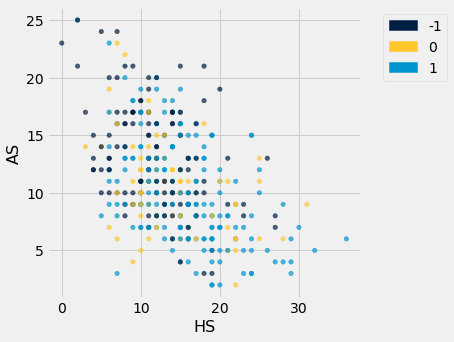

In [67]:
games.scatter('HS', 'AS', colors='winlose')

In [68]:
games

FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,winlose
2,1,1,0,8,13,6,4,11,8,2,5,2,1,0,0,1
2,0,1,0,12,10,4,1,11,9,7,4,1,1,0,0,1
0,2,0,1,15,10,6,9,9,11,5,5,1,2,0,0,-1
0,3,0,2,6,13,1,4,9,8,2,5,2,1,0,0,-1
1,2,1,2,15,15,2,5,11,12,3,5,2,2,0,0,-1
2,0,1,0,19,6,5,0,10,16,8,2,2,2,0,0,1
2,2,1,1,11,6,4,5,8,7,3,6,0,1,0,1,0
0,2,0,1,9,17,3,8,11,14,2,9,2,2,0,0,-1
4,0,2,0,18,5,8,2,14,9,5,4,1,2,0,0,1
0,0,0,0,18,16,3,6,10,9,8,5,0,1,0,0,0


## Distance ##

In [69]:
def distance(pt1, pt2):
    """Return the distance between two points, represented as arrays"""
    return np.sqrt(sum((pt1 - pt2)**2))

In [70]:
def row_distance(row1, row2):
    """Return the distance between two numerical rows of a table"""
    return distance(np.array(row1), np.array(row2))

In [71]:
attributes = games.drop('FTR')
attributes.show(3)

FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,winlose
2,1,1,0,8,13,6,4,11,8,2,5,2,1,0,0,1
2,0,1,0,12,10,4,1,11,9,7,4,1,1,0,0,1
0,2,0,1,15,10,6,9,9,11,5,5,1,2,0,0,-1


In [72]:
row_distance(attributes.row(4), attributes.row(3))

10.583005244258363

In [73]:
##example show we have the distances
row_distance(attributes.row(0), attributes.row(2))

10.862780491200215

In [74]:
##example show the same point compared to itself
row_distance(attributes.row(2), attributes.row(2))

0.0

# The Classifier

In [75]:
def distances(training, example):
    """Compute distance between example and every row in training.
    Return training augmented with Distance column"""
    distances = make_array()
    attributes_only = training.drop('Class')
    
    for row in attributes_only.rows:
        distances = np.append(distances, row_distance(row, example))
    
#   ^ SAME AS DOING:
#
#   for i in np.arange(attributes_only.num_rows):
#       row = attributes_only.row(i)
#       distances = np.append(distances, row_distance(row, example))
        
    return training.with_column('Distance_to_ex', distances)

In [76]:
example = attributes.row(18)
example

Row(FTHG=6, FTAG=1, HTHG=3, HTAG=1, HS=32, AS=5, HST=14, AST=1, HF=9, AF=4, HC=10, AC=3, HY=0, AY=2, HR=0, AR=0, winlose=1)

In [77]:
distances(games.exclude(18), example).sort('Distance_to_ex')

FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,winlose,Distance_to_ex
2,0,0,0,29,3,12,1,11,7,12,0,2,0,0,1,1,8.88819
3,0,2,0,28,9,9,3,7,7,10,4,0,0,0,0,1,9.53939
2,0,0,0,26,5,10,1,8,5,8,2,1,0,0,0,1,9.53939
2,0,1,0,29,4,9,0,9,10,10,2,1,1,0,0,1,9.84886
5,0,1,0,24,5,10,0,11,5,10,1,2,2,0,0,1,10.0499
2,2,0,0,28,6,9,4,10,9,11,3,1,3,0,0,0,10.3923
3,0,2,0,24,3,9,0,6,3,12,1,1,0,0,1,1,11.4018
3,1,1,0,25,10,11,3,9,5,5,2,0,0,0,0,1,11.4891
1,0,0,0,30,7,7,2,10,9,8,2,2,4,0,0,1,11.5326
2,0,1,0,28,4,8,1,4,10,10,3,0,3,0,0,1,11.7047


In [78]:
def closest(training, example, k):
    """Return a table of the k closest neighbors to example"""
    return distances(training, example).sort('Distance_to_ex').take(np.arange(k))

In [79]:
closest(games.exclude(18), example, 5)

FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,winlose,Distance_to_ex
2,0,0,0,29,3,12,1,11,7,12,0,2,0,0,1,1,8.88819
3,0,2,0,28,9,9,3,7,7,10,4,0,0,0,0,1,9.53939
2,0,0,0,26,5,10,1,8,5,8,2,1,0,0,0,1,9.53939
2,0,1,0,29,4,9,0,9,10,10,2,1,1,0,0,1,9.84886
5,0,1,0,24,5,10,0,11,5,10,1,2,2,0,0,1,10.0499


In [80]:
closest(games.exclude(18), example, 3).group('winlose').sort('count', descending=True)

winlose,count
1,3


In [81]:
def majority_class(topk):
    """Return the class with the highest count"""
    return topk.group('winlose').sort('count', descending=True).column(0).item(0)

In [82]:
def classify(training, example, k):
    "Return the majority class among the k nearest neighbors of example"
    return majority_class(closest(training, example, k))

In [83]:
classify(games.exclude(18), example, 3)

1

In [84]:
games.take(18)

FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,winlose
6,1,3,1,32,5,14,1,9,4,10,3,0,2,0,0,1


In [85]:
new_example = attributes.row(10)
classify(games.exclude(10), new_example, 5)

0

In [86]:
games.take(10)

FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,winlose
0,0,0,0,12,12,1,6,14,16,5,5,2,2,0,1,0


In [87]:
another_example = attributes.row(15)
classify(games.exclude(15), another_example, 5)

1

In [88]:
games.take(15)

FTHG,FTAG,HTHG,HTAG,HS,AS,HST,AST,HF,AF,HC,AC,HY,AY,HR,AR,winlose
1,2,1,0,11,12,5,5,14,10,6,4,6,2,0,0,-1


## Review of the Steps ##

- `distance(pt1, pt2)`: Returns the distance between the arrays `pt1` and `pt2`
- `row_distance(row1, row2)`: Returns the distance between the rows `row1` and `row2`
- `distances(training, example)`: Returns a table that is `training` with an additional column `'Distance'` that contains the distance between `example` and each row of `training`
- `closest(training, example, k)`: Returns a table of the rows corresponding to the k smallest distances 
- `majority_class(topk)`: Returns the majority class in the `'Class'` column
- `classify(training, example, k)`: Returns the predicted class of `example` based on a `k` nearest neighbors classifier using the historical sample `training`

## Accuracy of a Classifier ##

In [89]:
##get number of columns and rows and print it
total_rows= len(games[0])
total_cols=len(games)
print("Number of Rows: "+str(total_rows))
print("Number of Columns: "+str(total_cols))

Number of Rows: 380
Number of Columns: 17


In [90]:
shuffled = games.sample(with_replacement=False) # Randomly permute the rows
training_set = shuffled.take(np.arange(190))
test_set  = shuffled.take(np.arange(190, 380))

In [91]:
def evaluate_accuracy(training, test, k):
    """Return the proportion of correctly classified examples 
    in the test set"""
    test_attributes = test.drop('winlose')
    num_correct = 0
    for i in np.arange(test.num_rows):
        c = classify(training, test_attributes.row(i), k)
        num_correct = num_correct + (c == test.column('winlose').item(i))
    return num_correct / test.num_rows

In [92]:
evaluate_accuracy(training_set, test_set, 3)

ValueError: operands could not be broadcast together with shapes (17,) (16,) 

In [41]:
evaluate_accuracy(training_set, test_set, 3)

0.9648093841642229

In [36]:
evaluate_accuracy(training_set, test_set, 11)

0.9472140762463344

In [37]:
evaluate_accuracy(training_set, test_set, 1)

0.9560117302052786